# North San Andreas fault M7.6 Scenario - Part B - Ground Failure

This notebook should be run in the gf conda environment. To specify that, either click "Select Kernal" in the upper right corner or it will prompt you to select a kernal when you run the first cell.

Then select "Python Environments" --> "gf (Python 3.10.20)"

# 1. Command line execution
In the first section, we'll learn the easiest way to run the ground failure models using the command line function "gfailbin" from the terminal. 

You can run these commands in this notebook as demonstrated below, or alternatively, go to the Terminal, type "conda activate gf" to initialize the gf environment, and then you can run the commands listed below directly in the terminal.

## gfailbin

There are 6 command line programs available in groundfailure ([see full list](https://code.usgs.gov/ghsc/esi/groundfailure/groundfailure/-/blob/main/README.md?ref_type=heads#documentation)), but most are for USGS-specific operational uses. Other users will only need the ```gfailbin``` program.

Let's start by printing out the help information for ```gfailbin```:

In [1]:
%%bash
gfailbin -h

usage: gfailbin [-h] [-a [appendname]] [-c [configfilepath]]
                [-d [datafilepath]] [-pf [popfile]] [-o [outfilepath]]
                [-u [uncertfile]] [-tr [trimocean]] [-pdl [pdlconfig]]
                [-comcat [comcatconfig]] [-log [logfilepath]] [--debug]
                [-db [dbfile]] [-b [latmin, latmax, lonmin, lonmax]]
                [-f [finitefault]] [-s [numstd]] [-gv [gf_version]] [--gis]
                [--kmz] [--hdf5] [-i] [-l] [-set] [-reset] [-w] [-ext]
                [--property-alertlevel PROPERTY_ALERTLEVEL]
                [--eventsource EVENTSOURCE]
                [--eventsourcecode EVENTSOURCECODE] [--scenario]
                [config] [shakefile]

Run ground failure models on input ShakeMap grid.

positional arguments:
  config                single config file of model to run (.ini extension),
                        or text file listing config files (do not use .ini
                        extension) (default: None)
  shakefile             si

 We see that there are two required positional arguments and numerous optional arguments.

 ### Required arguments:
 These two arguments must be in exactly the order specified or the program will not run:
 * ```config```: tells the program what ground failure model(s) to run. Should be a file path of either:
    * a single model configuration .ini file ([example](https://code.usgs.gov/ghsc/esi/groundfailure/groundfailure/-/blob/main/defaultconfigfiles/models/jessee_2018.ini?ref_type=heads)) or,
    * a .txt file listing several model configuration .ini files to run, one on each line
* ```shakefile```: tells the program what ShakeMap to use as the shaking input. This can be either a file path to a locally saved ShakeMap grid.xml file OR the url to a ShakeMap from the USGS website. This can be found by going to the ShakeMap product page for the desired event ([example](https://earthquake.usgs.gov/earthquakes/eventpage/us6000jllz/shakemap/intensity)), and navigating to the "XML Grid" section of the Downloads.
 
### Optional arguments:
 Many of the optional arguments are only for USGS operational use and can be ignored, those that are most of interest for our uses are the following arguments that tell the program:
* What outputs to create: [```-w, --gis, --kmz```] - at least one of these needs to be specified:
    * ```--gis```: outputs geotiff files in the WGS84 coordinate system of raw model probabilities for each model specified in ```config```, these files must then be stylized by the user afterwards for display (e.g. in QGIS)
    * ```--kmz```: outputs stylized kmz files of the model probabilities (e.g. for viewing in Google Earth). Note that this image is downgraded relative to the geotiffs.
    * ```-w``` or ```--make-webpage```: Compute summary statistics and creates all of the files need to product the the ground failure product summary page (e.g., alert levels). This is for operational use and only works if the preferred [landslide](https://code.usgs.gov/ghsc/esi/groundfailure/groundfailure/-/blob/main/defaultconfigfiles/models/jessee_2018.ini?ref_type=heads) and [liquefaction](https://code.usgs.gov/ghsc/esi/groundfailure/groundfailure/-/blob/main/defaultconfigfiles/models/zhu_2017_general_slim.ini?ref_type=heads) models are listed in ```config```, but we will use this today to simulate the alert level summary statistics for the scenarios. 

* Where the input files are [```-c, -d, -pf```]: 
    * ```-c``` or ```configfilepath``` tells the program the folder to search for the .ini model configuration files specified in the ```config``` argument. If you are using the [default model configuration files exactly](https://code.usgs.gov/ghsc/esi/groundfailure/groundfailure/-/tree/main/defaultconfigfiles/models?ref_type=heads), this does not need to be specified because the program will automatically find them.
    * ```-d``` or ```datafilepath``` tells the program where to find the input files that are specified in each model's .ini file. For this California example, this is the [/data/california_inputs](https://github.com/smithUSGS/shakemap-gf-workshop/tree/main/data/california_inputs) folder
    * ```-pf``` or ```--popfile```: this tells the program where to find the population file needed to compute the population exposure alert levels. This is only needed if the ```--make-webpage``` flag is set and won't be used otherwise.

* Where to put the outputs [```-o```, ```-ext```]: ```-o``` tells the program what folder to put the outputs in. Unless the ```--ext``` flag is also set, it will create a new subfolder using the ShakeMap's eventid code.
* That this run is a scenario [```--scenario```]: tells the program that this run is a scenario, not a real event. This is not strictly required except for operational use.

## Setting default file paths

Since we are always going to be using some of the same input and output file locations, we can use ```gfailbin``` to set those once as defaults using the ```-set``` or ```--set-default-paths```. This creates a file called ```.gfail_defaults``` in your main user directory that can also be manually edited. Let's set the defaults that will always be the same for this workshop. Note: we don't set the datafilepath or population file path because those will vary for different notebooks in this workshop, so we will set those manually for each run instead.

In [26]:
%%bash
# make the output directory
export OUTDIR=/home/vscode/gf_output
mkdir $OUTDIR
# specify location of default configuration files
export DEFAULTCONFIGPATH=/home/vscode/groundfailure/defaultconfigfiles/models

# clear any pre-existing default paths
gfailbin --reset-default-paths
# Set the defaults
gfailbin --set-default-paths -c $DEFAULTCONFIGPATH -o $OUTDIR

mkdir: cannot create directory ‘/home/vscode/gf_output’: File exists


Default paths cleared

New default paths set.

Default paths currently set to:

	output_filepath = /home/vscode/gf_output
	config_filepath = /home/vscode/groundfailure/defaultconfigfiles/models
default paths set, continuing...



We can then check what the current default paths are set to in two ways:

In [27]:
%%bash
# using gfailbin command
gfailbin --list-default-paths
# looking at the hidden file we created using --set-default-paths
cat ~/.gfail_defaults

Default paths currently set to:

	output_filepath = /home/vscode/gf_output
	config_filepath = /home/vscode/groundfailure/defaultconfigfiles/models
output_filepath = /home/vscode/gf_output
config_filepath = /home/vscode/groundfailure/defaultconfigfiles/models


## Preparing the models to run

For this scenario, we will run just the two "preferred" ground failure models and will produce the outputs that are used to generate the USGS Ground Failure product webpage.

The two "preferred" models used by the USGS to produce the Ground Failure product are:
- **Landslide probability** — Nowicki Jessee et al. (2018): uses slope, PGV, lithology, and ground cover
- **Liquefaction probability** — Zhu et al. (2017): uses Vs30, distance to water, and mean annual precipitation

The inputs required for each model and other details are found in their corresponding model configuration files, which are in .ini format. Let's first look at the .ini file for the Nowicki Jessee et al. (2018) landslide model:

In [5]:
%%bash
cat /home/vscode/groundfailure/defaultconfigfiles/models/jessee_2018.ini

[jessee_2018]
  #Detailed description of the model, its inputs, etc.
  description = 'This is the Nowicki Jessee Model, which uses lithology, and land cover.'
  longref = 'Nowicki Jessee, M.A., Hamburger, H.W., Allstadt, K.E., Wald, D.J., Robeson, S.M., Tanyas, H., Hearne, M., Thompson, E.M., 2018, A Global Empirical Model for Near Real-time Assessment of Seismically Induced Landslides, J. Geophys. Res. Earth Surface, 123, 1835-1859'
  shortref = 'Nowicki Jessee and others (2018)'
  
  #which type of ground failure model is this? Options are landslide or liquefaction.
  gfetype = landslide

  #what is the grid to which all other grids in this model will be resampled?
  baselayer = slope 

  slopemin = 2. # in degrees
  slopemax = 90. # in degrees
  slopefile = global_grad.tif
  # slopemod = np.arctan(slope) * 180 / np.pi  # Modification of slopefile to convert to degrees (optional)

  # Minimum ground motion threshold for doing calculations
  minpga = 2. # %g  (2%g is from Jibson and H

The model .ini file tells the code what kind of model it is, what input files to use, along with other information (e.g., interpolation, display, masking). Normally we do not need to edit this file except to change the base file names of some of the inputs. All inputs need to be in the same folder.

The model coefficients for models of this type (logistic models) are in a corresponding .py file for each model ([example](https://code.usgs.gov/ghsc/esi/groundfailure/groundfailure/-/blob/main/src/gfail/models/jessee_2018.py?ref_type=heads))

For this scenario, we have provided the input files needed for the "slim" version of the preferred files in the /data/california_inputs folder. The slim models pre-combine multiple static input layers into one input file to save storage space and reduce computational demands, so we will run ```zhu_2017_general_slim.ini``` and ```jessee_2018_slim.ini```. Let's create a .txt file listing these two files that we will need to run both models at the same time:

In [13]:
%%bash
# Set the bash variable name for the configuration file path
export CONFIG=/workspaces/shakemap-gf-workshop/data/gf_configs_ca.txt
# Create the file
cat << 'EOF' > $CONFIG
jessee_2018_slim.ini
zhu_2017_general_slim.ini
EOF

# Print out the file
cat $CONFIG

jessee_2018_slim.ini
zhu_2017_general_slim.ini


Note that we do not need to include the full file paths because we are using the default configuration files so the codes will know where to look.

## Running the scenario

Now we are ready to run the San Andreas scenario! It's just one simple command, but we use some bash variables below to keep things organized and clear. 

Notes: 
* we have to specifically define the location of the model input files and population file for this scenario since the files are located in different places for the different scenarios for this workshop.
* the ```--gis``` and ```--kmz``` flags are not actually needed because the ```-w``` flag automatically includes those outputs, but we have included them here for illustrative purposes since they are commonly used flags and we will not always be using the ```-w``` flag in this workshop.
* this will only work if you have already created the ShakeMap grid.xml file by running the San Andreas scenario in notebook 01

In [14]:
%%bash
# list of models to run
export CONFIG=/workspaces/shakemap-gf-workshop/data/gf_configs_ca.txt
# Input data folder
export DATADIR=/workspaces/shakemap-gf-workshop/data/california_inputs
# Population file
export POPFILE=$DATADIR/cali_GHS_POP_E2025.tif
# Location of grid.xml for scenario that was created in the previous notebook
export EVENT=bssc2014nsanandreassapsassha_m7p6_se
export SHAKEFILE=~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml
# Location of uncertainty file (optional, but is needed to estimate ground failure model uncertainties)
export UNCERTFILE=~/shakemap_profiles/default/data/$EVENT/current/products/uncertainty.xml

gfailbin $CONFIG $SHAKEFILE -d $DATADIR -pf $POPFILE -u $UNCERTFILE -w --gis --kmz


Running the following models:
	jessee_2018_slim
	zhu_2017_general_slim
Applying bounds of lonmin -124.40, lonmax -118.89, latmin 34.79, latmax 40.10
Unable to determine source type, unknown if finite fault or point source

Now running jessee_2018_slim:

Now running zhu_2017_general_slim:

Files created:

/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/shakefile.txt
bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim.hdf5
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.tif
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.kmz
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_beta_sigma.tif
bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim.hdf5
/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_

## Outputs

Let's look at the files that were output:

In [16]:
%%bash
ls /home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se

bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim.hdf5
bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_beta_sigma.tif
bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.kmz
bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.tif
bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim.hdf5
bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_beta_sigma.tif
bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_model.kmz
bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_model.tif
grid.xml
info.json
jessee_2018.png
jessee_2018_extent.json
shakefile.txt
uncertainty.xml
zhu_2017_general.png
zhu_2017_general_extent.json


* The .tif files are the geotiffs of the raw probabilities output by each model (the *_beta_sigma.tif files are for uncertainty calculations and can be ignored)
* The .kmz files are the stylized files that can be viewed in Google Earth
* The info.json file contains the Ground Failure Product summary information displayed on the USGS webpages.
* The rest of the files can be ignored, e.g., many are for webpage rendering.

### Interactive ground failure map

Groundfailure does not natively produce any maps because it is designed as operational software and the results are to be rendered on the USGS webpages. The .tif files can be viewed in QGIS using the Website_colormap.qml style to replicate the USGS Interactive Map and the .kmz files can be viewed in Google Earth (demo outside notebook)

We have also created an interactive viewer for this workshop to easily browse the results and see the summary alert information. Run the next few cells to create and view the results interactively

The map shows landslide (left) and liquefaction (right) probability side by side, with shaking contours overlaid and the hazard and exposure alert levels for each ground failure type reported at the bottom

In [ ]:
%%bash
export EVENT=bssc2014nsanandreassapsassha_m7p6_se
/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --model "Jessee2018:$HOME/gf_output/$EVENT/${EVENT}_jessee_2018_slim_model.tif:$HOME/groundfailure/defaultconfigfiles/models/jessee_2018_slim.ini" \
  --model "Zhu2017:$HOME/gf_output/$EVENT/${EVENT}_zhu_2017_general_slim_model.tif:$HOME/groundfailure/defaultconfigfiles/models/zhu_2017_general_slim.ini" \
  --shakefile ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --contours  ~/shakemap_profiles/default/data/$EVENT/current/products/cont_mmi.json \
  --infojson  ~/gf_output/$EVENT/info.json \
  --outfile ~/san_andreas_gf.html

Reading /home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_jessee_2018_slim_model.tif...
Reading /home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/bssc2014nsanandreassapsassha_m7p6_se_zhu_2017_general_slim_model.tif...
Saved: /home/vscode/san_andreas_gf.html
[Jessee2018] max P: 0.2372, area>0.002: 6.1%
[Zhu2017] max P: 0.4280, area>0.005: 29.9%


In [19]:
from pathlib import Path
import base64
from IPython.display import HTML

html_path = Path.home() / 'san_andreas_gf.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

/opt/conda/envs/gf/lib/python3.10/site-packages/IPython/core/display.py:475: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


---

## Alert levels and other info in info.json

We see above that this scenario has a "Red" alert for both landslide hazard and population exposure, and an orange alert for liquefaction hazard, but red for population exposure.

These alert levels are calibrated to historical earthquakes and are determined by summing up the probability values scaled by either area or population as described on the [Ground Failure Scientific Background webpage](https://earthquake.usgs.gov/data/ground-failure/background.php).

All of this information and more summary information is included in the info.json file, let's explore it:

In [24]:
import json

# Load and print with 4-space indentation
with open('/home/vscode/gf_output/bssc2014nsanandreassapsassha_m7p6_se/info.json', 'r') as file:
    data = json.load(file)
    print(json.dumps(data, indent=4))

{
    "Summary": {
        "code": "nsanandreassapsassha_m7p6_se",
        "net": "bssc2014",
        "magnitude": 7.6,
        "depth": 7.8,
        "time": "2017-06-30T16:03:44Z",
        "lat": 37.2972,
        "lon": -122.1401,
        "location": "N. San Andreas: SAP+SAS",
        "event_url": "https://earthquake.usgs.gov/earthquakes/eventpage/bssc2014nsanandreassapsassha_m7p6_se#executive",
        "gf_version": 1,
        "gf_time": "2026-08-28T14:45:39Z",
        "shakemap_version": 1,
        "shakemap_source": "us",
        "shakemap_time": "2026-08-28T14:40:43Z",
        "rupture_warning": false,
        "point_source": false,
        "zoom_extent": [
            -123.08125000000001,
            -120.63958333333335,
            36.40208333333333,
            38.46875
        ],
        "realtime": false,
        "event_type": "SCENARIO"
    },
    "Landslides": [
        {
            "id": "jessee_2018",
            "title": "Nowicki Jessee and others (2018)",
            "

# 2. Running Groundfailure in Python

The gfailbin program is just a wrapper around a set of python functions. Those can also just be used directly if the user wants more control and wants to explore some of the intermediate steps. We will demonstrate how this works briefly here, this time, to run two different liquefaction models and compare them.

## Import models and set file paths

In [37]:
from configobj import ConfigObj
import os
import matplotlib.pyplot as plt

#local imports
from gfail import (
    Zhu2015ModelSlim,
    Zhu2017ModelSlim,
)
from gfail.utilities import parseConfigLayers, correct_config_filepaths
from gfail.webpage import create_kmz
%matplotlib inline

# Set file paths
# Directory containing model inputs
datadir = '/workspaces/shakemap-gf-workshop/data/california_inputs'

# Path to config files
configfileZ15 = '/home/vscode/groundfailure/defaultconfigfiles/models/zhu_2015_slim.ini'
configfileZ17 = '/home/vscode/groundfailure/defaultconfigfiles/models/zhu_2017_general_slim.ini'

# Path to shakemap .xml files
shakefile = '/home/vscode/shakemap_profiles/default/data/bssc2014nsanandreassapsassha_m7p6_se/current/products/grid.xml'
uncertfile = '/home/vscode/shakemap_profiles/default/data/bssc2014nsanandreassapsassha_m7p6_se/current/products/uncertainty.xml'

## Run both liquefaction models
The Zhu et al. 2015 model was the earliest liquefaction model used by the operational system. It is still run as an alternate model by the USGS Ground Failure product but is not displayed and is only available as a download.

In [41]:
# Run Zhu 2015
configZ15 = ConfigObj(configfileZ15)
# add the full file extensions to all the input file paths
configZ15 = correct_config_filepaths(datadir, configZ15)

# In this model, you first define the class, then calculate the model
lmz15 = Zhu2015ModelSlim(shakefile, configZ15["zhu_2015_slim"])
maplayers_z15 = lmz15.calculate()

# Run Zhu 2017 general (current preferred model)
configZ17 = ConfigObj(configfileZ17)
# add the full file extensions to all the input file paths
configZ17 = correct_config_filepaths(datadir, configZ17)
lmz17 = Zhu2017ModelSlim(shakefile, configZ17["zhu_2017_general_slim"])
maplayers_z17 = lmz17.calculate()

## Plot a quick side by side comparison for San Franciso Bay area

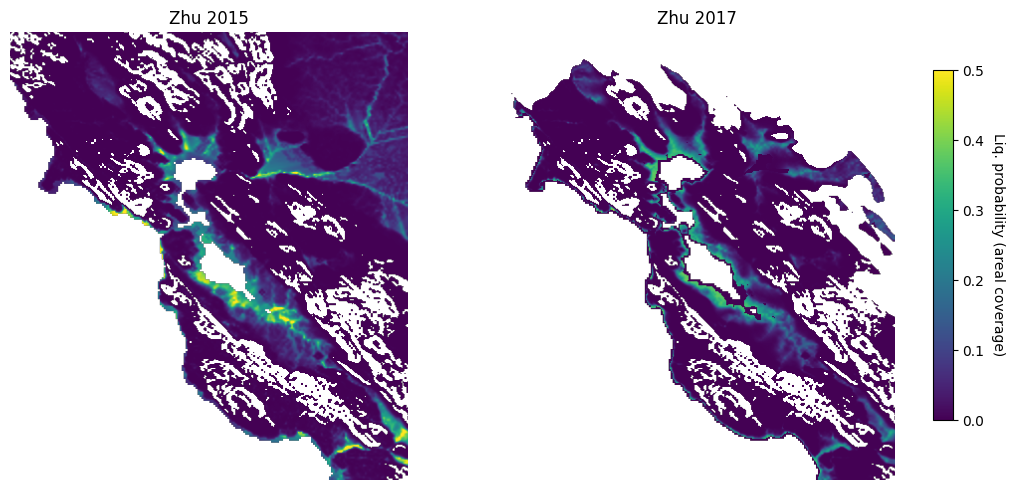

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax1.imshow(maplayers_z15['model']['grid'].getData(), vmin=0, vmax=0.5)
ax1.set_title("Zhu 2015")
ax1.axis("off")  # Optional: hides tick marks and borders

im2 = ax2.imshow(maplayers_z17['model']['grid'].getData(), vmin=0, vmax=0.5)
ax2.set_title("Zhu 2017")
ax2.axis("off")  # Optional: hides tick marks and borders

ax1.set_ylim([800, 350])
ax1.set_xlim([300, 700])

cax = fig.add_axes([0.98, 0.15, 0.02, 0.7]) 
cbar = fig.colorbar(im2, cax=cax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Liq. probability (areal coverage)", rotation=270, labelpad=15)

# 5. Clean up layout and display
plt.tight_layout()
plt.show()